# IC Quant Project - v4

Based on **v3** with one change to address near-zero prediction bias:

* **Volatility-normalized target** - predict next `HORIZON=5` day log return divided by rolling `VOL_WINDOW=20` standard deviation of daily returns. Model output is a realised-Sharpe-like quantity; `predict_next()` multiplies by current volatility to recover an actual return estimate.

Retains from v3: IC Loss, cross-asset features, ReduceLROnPlateau scheduler.


# Google Colab Setting

In [ ]:
!pip install -q "numpy<2.0" "pandas<2.2" refinitiv-data fredapi optuna xgboost tqdm scikit-learn

# Package imports

In [1]:
import os
os.environ["KMP_DUPLICATE_LIB_OK"] = "TRUE"
os.environ["OMP_NUM_THREADS"] = "1"
os.environ["MKL_NUM_THREADS"] = "1"

In [2]:
import pandas as pd
import numpy as np
import refinitiv.data as rd
from fredapi import Fred

import datetime as dt
import json
import os
import joblib

from sklearn.preprocessing import StandardScaler
from xgboost import XGBRegressor
from scipy.cluster.hierarchy import linkage, fcluster
from scipy.spatial.distance import squareform

import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
import optuna
import matplotlib.pyplot as plt
from tqdm.auto import tqdm

/Users/ahnsebin/Documents/GeorgiaTech/Spring26/GTSF IC/project/.venv/lib/python3.11/site-packages/tqdm/auto.py:21:TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html


# Data Acquisition

In [3]:
START = "2000-01-01"
END = dt.datetime.today().strftime("%Y-%m-%d")

REFINITIV_TICKERS = ["SPY", "TLT.O", "GLD", "XLE", ".DXY"]
TARGET_TICKERS = ["SPY", "TLT.O", "GLD", "XLE"]

FRED_TICKERS = {
    "T10Y2Y":     "Term_Spread",
    "BAA10Y":     "Credit_Spread",
    "T10YIE":     "Breakeven_Inflation",
    "VIXCLS":     "VIX",
    "NASDAQXAU":  "Gold_Spot",
    "DCOILWTICO": "WTI_Crude",
}

OUT_PATH = "../data/merged_daily.csv"
DATASET_DIR = "../data"

# SAVE_DIR = "/content/drive/MyDrive/Personal Projects/IC Quant/project/model/transformer"  # Google Colab
SAVE_DIR = "../model"

MACRO_LEVEL_DIFF = ["Term_Spread", "Credit_Spread", "Breakeven_Inflation", "VIX"]
MACRO_LOG_RETURN = ["Gold_Spot", "WTI_Crude"]


In [ ]:
def key_loader(filepath):
    try:
        with open(filepath) as f:
            app_key = json.load(f)['sessions']['platform']['rdp']['app-key']
        print("Key loaded successfully")
        return app_key
    except FileNotFoundError:
        print(f"Error: '{filepath}' not found.")
        raise
    except KeyError as e:
        print(f"Error: missing key {e}.")
        raise


In [ ]:
def check_state(state, message, session):
    print(f"State: {state}")
    print(f"Message: {message}")
    print("\n")

In [ ]:
def fetch_refinitiv_data(tickers, start_date, end_date, app_key):
    """
    Fetch target assets' OHLCV and adjusted prices from Refinitiv Data API.
    
    :param tickers: list of ticker symbols
    :param start_date: start date (YYYY-MM-DD)
    :param end_date: end date (YYYY-MM-DD)
    :param app_key: Refinitiv app key
    :return: DataFrame with OHLCV data
    """
    session = None
    try:
        session = rd.session.desktop.Definition(app_key=app_key).get_session()
        rd.session.set_default(session)
        session.on_state(check_state)
        session.open()

        fields = [
            "TR.PriceOpen",
            "TR.PriceHigh",
            "TR.PriceLow",
            "TR.PriceClose",
            "TR.Volume"
        ]

        frames = []
        for ticker in tickers:
            print(f"[REFINITIV] Fetching {ticker} ...")
            try:
                tdf = rd.get_history(
                    universe=[ticker],
                    fields=fields,
                    interval="1D",
                    start=start_date,
                    end=end_date
                )

                if tdf is None or tdf.empty:
                    print(f"[REFINITIV] {ticker}: EMPTY")
                    continue

                tdf.index = pd.to_datetime(tdf.index)
                try:
                    tdf.index = tdf.index.tz_localize(None)
                except (TypeError, AttributeError):
                    pass

                # Remove duplicate dates from Refinitiv (can occur at DST boundary)
                tdf = tdf[~tdf.index.duplicated(keep='last')]

                if isinstance(tdf.columns, pd.MultiIndex):
                    tdf.columns = [f"{tic}_{fld}" for tic, fld in tdf.columns]
                else:
                    tdf.columns = [f"{ticker}_{col}" for col in tdf.columns]

                print(f"[REFINITIV] {ticker}: OK | rows={len(tdf)} | {tdf.index.min().date()} -> {tdf.index.max().date()}")
                frames.append(tdf)
            except Exception as e:
                print(f"[REFINITIV] {ticker}: FAIL | {e}")

        if not frames:
            raise ValueError("No Refinitiv data was fetched successfully.")

        df = pd.concat(frames, axis=1).sort_index()
        return df
    finally:
        if session is not None:
            session.close()

In [ ]:
def fetch_fred_data(tickers_dict, start_date, end_date):
    """
    Fetch macro and alternative indicators using the fredapi library.
    Key resolution: $FRED_API_KEY -> secrets.json -> error.
    """
    api_key = os.environ.get("FRED_API_KEY")
    if not api_key:
        with open("secrets.json") as f:
            api_key = json.load(f)["fred_api_key"]

    fred = Fred(api_key=api_key)
    combined_fred_data = pd.DataFrame()

    for ticker, name in tickers_dict.items():
        print(f"[FRED] Fetching {ticker} ({name}) ...")
        try:
            series = fred.get_series(ticker, observation_start=start_date, observation_end=end_date)
            if series is None or len(series) == 0:
                print(f"[FRED] {ticker}: EMPTY")
                continue

            combined_fred_data[name] = series
            sidx = pd.to_datetime(series.index)
            print(f"[FRED] {ticker}: OK | rows={len(series)} | {sidx.min().date()} -> {sidx.max().date()}")
        except Exception as e:
            print(f"[FRED] {ticker}: FAIL | {e}")

    combined_fred_data.index = pd.to_datetime(combined_fred_data.index)
    return combined_fred_data


In [ ]:
def get_raw_dataset(start_date=START, end_date=END, filepath='refinitiv-data.config.json'):
    app_key = key_loader(filepath)
    df_market = fetch_refinitiv_data(REFINITIV_TICKERS, start_date, end_date, app_key)
    df_macro = fetch_fred_data(FRED_TICKERS, start_date, end_date)

    df_merged = df_market.join(df_macro, how="left")
    df_merged = df_merged.apply(pd.to_numeric, errors='coerce')
    df_merged = df_merged.ffill()

    close_cols = [f"{t}_Price Close" for t in TARGET_TICKERS
                  if f"{t}_Price Close" in df_merged.columns]
    df_merged = df_merged.dropna(subset=close_cols, how='any')
    df_merged = df_merged.drop([".DXY_Volume"], axis=1, errors="ignore")

    return df_merged


In [ ]:
filepath = 'refinitiv-data.config.json'
df = get_raw_dataset(filepath=filepath)
print(f"Data shape: {df.shape}")
print(f"Date range: {df.index.min()} to {df.index.max()}")

In [ ]:
df

In [ ]:
df.to_csv(OUT_PATH)

# Data Preprocessing

In [4]:
df = pd.read_csv(OUT_PATH, index_col=0, parse_dates=True)

In [5]:
def transform_macro(df, level_diff_cols, log_return_cols):
    out = pd.DataFrame(index=df.index)
    for col in level_diff_cols:
        if col in df.columns:
            out[f"{col}_level"] = df[col]
            out[f"{col}_diff"] = df[col].diff()
    for col in log_return_cols:
        if col in df.columns:
            out[f"{col}_logret"] = np.log(df[col].clip(lower=1e-10) / df[col].shift(1).clip(lower=1e-10))
    if ".DXY_Price Close" in df.columns:
        dxy = pd.to_numeric(df[".DXY_Price Close"], errors="coerce")
        out["DXY_logret"] = np.log(dxy.clip(lower=1e-10) / dxy.shift(1).clip(lower=1e-10))
    return out


# Feature Engineering

In [6]:
def compute_technical_features(close):
    out = pd.DataFrame(index=close.index)
    ret_1d = np.log(close / close.shift(1))
    out["ret_1d"] = ret_1d
    out["ret_5d"] = np.log(close / close.shift(5))
    out["ret_20d"] = np.log(close / close.shift(20))

    ema_12 = close.ewm(span=12, adjust=False).mean()
    ema_26 = close.ewm(span=26, adjust=False).mean()
    out["macd"] = ema_12 - ema_26

    delta = close.diff()
    gain = delta.clip(lower=0).ewm(alpha=1/14, adjust=False).mean()
    loss = (-delta.clip(upper=0)).ewm(alpha=1/14, adjust=False).mean()
    out["rsi_14"] = 100 - 100 / (1 + gain / loss)

    out["vol_20d"] = ret_1d.rolling(20).std() * np.sqrt(252)
    return out

def build_cross_asset_returns(df, targets):
    """v3: cross-asset daily log returns for feature augmentation."""
    out = {}
    for t in targets:
        close = df[f"{t}_Price Close"]
        out[f"{t}_ret_1d"] = np.log(close / close.shift(1))
    return pd.DataFrame(out, index=df.index)

def build_target_dataset(df, target, macro_features, cross_rets):
    """v4: volatility-normalized t+HORIZON return as target.
    target_t = log(close_{t+H} / close_t) / rolling_std(ret_1d, VOL_WINDOW)

    Prediction output is a 'realised Sharpe' - multiply by current vol
    to recover an actual return estimate.
    """
    close = df[f"{target}_Price Close"]
    tech  = compute_technical_features(close).add_prefix(f"{target}_")
    cross = cross_rets.drop(columns=[f"{target}_ret_1d"], errors="ignore")

    # v4: volatility-normalized multi-step target
    raw_ret  = np.log(close.shift(-HORIZON) / close)
    ret_1d   = np.log(close / close.shift(1))
    roll_vol = ret_1d.shift(1).rolling(VOL_WINDOW).std().clip(lower=1e-6)
    y        = (raw_ret / roll_vol).rename("target")

    return pd.concat([tech, macro_features, cross, y], axis=1).dropna()


In [9]:
macro_features = transform_macro(df, MACRO_LEVEL_DIFF, MACRO_LOG_RETURN)
cross_rets    = build_cross_asset_returns(df, TARGET_TICKERS)   # v3: cross-asset returns
datasets = {t: build_target_dataset(df, t, macro_features, cross_rets) for t in TARGET_TICKERS}

for t, data in datasets.items():
    print(f"{t}: shape={data.shape}, range={data.index.min().date()} -> {data.index.max().date()}")


SPY: shape=(5562, 21), range=2004-12-17 -> 2026-04-13
TLT.O: shape=(5562, 21), range=2004-12-17 -> 2026-04-13
GLD: shape=(5562, 21), range=2004-12-17 -> 2026-04-13
XLE: shape=(5562, 21), range=2004-12-17 -> 2026-04-13


In [10]:
os.makedirs(DATASET_DIR, exist_ok=True)

for target, data in datasets.items():
    safe_name = target.replace(".", "_")
    data.to_csv(f"{DATASET_DIR}/{safe_name}_dataset.csv")
    print(f"Saved: {safe_name}_dataset.csv | shape={data.shape}")


Saved: SPY_dataset.csv | shape=(5562, 21)
Saved: TLT_O_dataset.csv | shape=(5562, 21)
Saved: GLD_dataset.csv | shape=(5562, 21)
Saved: XLE_dataset.csv | shape=(5562, 21)


# Feature Selection

In [11]:
# Load datasets from CSV
datasets = {}
for target in TARGET_TICKERS:
    safe_name = target.replace(".", "_")
    path = f"{DATASET_DIR}/{safe_name}_dataset.csv"
    datasets[target] = pd.read_csv(path, index_col=0, parse_dates=True)
    print(f"Loaded: {safe_name}_dataset.csv | shape={datasets[target].shape}")

Loaded: SPY_dataset.csv | shape=(5562, 21)
Loaded: TLT_O_dataset.csv | shape=(5562, 21)
Loaded: GLD_dataset.csv | shape=(5562, 21)
Loaded: XLE_dataset.csv | shape=(5562, 21)


## Correlation Test

In [12]:
SPEARMAN_THRESHOLD = 0.90
TOP_K = 12

def stage1_redundancy_filter(X, y, threshold=SPEARMAN_THRESHOLD):
    corr = X.corr(method='spearman').abs()
    dist = (1 - corr).clip(lower=0)
    dist_arr = dist.values.copy()
    np.fill_diagonal(dist_arr, 0)
    condensed = squareform(dist_arr, checks=False)
    Z = linkage(condensed, method='ward')
    labels = fcluster(Z, t=1 - threshold, criterion='distance')
    ic = X.corrwith(y, method='spearman').abs()
    selected = []

    for cid in np.unique(labels):
        cols = X.columns[labels == cid].tolist()
        selected.append(ic[cols].idxmax())
    return selected

## XGBoost Feature Importance

In [13]:
def stage2_relevance_filter(X, y, top_k=TOP_K):
    xgb_device = "cuda" if torch.cuda.is_available() else "cpu"
    model = XGBRegressor(
        max_depth=3, n_estimators=100, random_state=42, verbosity=0,
        device=xgb_device, tree_method="hist",
    )
    model.fit(X, y)
    importances = pd.Series(model.feature_importances_, index=X.columns)
    return importances.nlargest(top_k)   # Series (feature → importance)

In [14]:
def select_features(X, y, top_k=TOP_K):
    stage1 = stage1_redundancy_filter(X, y)
    stage2 = stage2_relevance_filter(X[stage1], y, top_k=top_k)
    return stage2.index.tolist(), stage2   # (feature_list, importance_series)

# VSN Embedding

In [15]:
LOOKBACK            = 20
INITIAL_TRAIN_YEARS = 5
TEST_SIZE           = 60
EMBARGO             = LOOKBACK
HORIZON             = 5    # v4: t+5 prediction horizon
VOL_WINDOW          = 20   # v4: rolling vol window for target normalization


def make_sequence_dataset(data, feature_cols, lookback=LOOKBACK):
    X = data[feature_cols].values.astype(np.float32)
    y = data["target"].values.astype(np.float32)
    xs, ys = [], []
    for i in range(lookback, len(data)):
        xs.append(X[i - lookback:i])
        ys.append(y[i])
    if not xs:
        return torch.empty(0, lookback, len(feature_cols)), torch.empty(0)
    return torch.tensor(np.array(xs)), torch.tensor(np.array(ys))

In [16]:
class GatedResidualNetwork(nn.Module):
    def __init__(self, input_dim, hidden_dim, dropout=0.1):
        super().__init__()
        self.fc1 = nn.Linear(input_dim, hidden_dim)
        self.fc2 = nn.Linear(hidden_dim, hidden_dim)
        self.dropout = nn.Dropout(dropout)
        self.gate = nn.Linear(hidden_dim, 2 * hidden_dim)
        self.skip = nn.Linear(input_dim, hidden_dim) if input_dim != hidden_dim else nn.Identity()
        self.norm = nn.LayerNorm(hidden_dim)

    def forward(self, x):
        z = torch.nn.functional.elu(self.fc1(x))
        z = self.fc2(z)
        z = self.dropout(z)
        a, b = self.gate(z).chunk(2, dim=-1)
        z = a * torch.sigmoid(b)
        return self.norm(z + self.skip(x))


In [17]:
class VariableSelectionNetwork(nn.Module):
    def __init__(self, num_features, hidden_dim, dropout=0.1):
        super().__init__()
        self.feature_grns = nn.ModuleList(
            [GatedResidualNetwork(1, hidden_dim, dropout) for _ in range(num_features)]
        )
        self.selection_grn = GatedResidualNetwork(num_features, num_features, dropout)

    def forward(self, x):
        # x: [batch, time, features]
        feat = torch.stack(
            [grn(x[:, :, i:i + 1]) for i, grn in enumerate(self.feature_grns)], dim=2
        )
        weights = torch.softmax(self.selection_grn(x), dim=-1).unsqueeze(-1)
        context = (feat * weights).sum(dim=2)
        return context, weights.squeeze(-1)


In [18]:
def expanding_window_folds(n, initial_train, test_size, embargo, purge=0):
    # purge: drop the last `purge` rows of each training set to remove samples
    # whose label horizon overlaps the embargo/test region. For daily t+1 targets
    # with embargo >= 1 this is already satisfied, so default is 0.
    folds = []
    train_end = initial_train
    while train_end + embargo + test_size <= n:
        train_idx = np.arange(0, max(train_end - purge, 1))
        test_start = train_end + embargo
        test_end = test_start + test_size
        test_idx = np.arange(test_start, test_end)
        folds.append((train_idx, test_idx))
        train_end += test_size
    return folds


# LSTM Model

In [19]:
if torch.cuda.is_available():
    DEVICE = "cuda"
    torch.backends.cudnn.benchmark = True
    torch.set_float32_matmul_precision("high")
elif torch.backends.mps.is_available():
    DEVICE = "mps"
else:
    DEVICE = "cpu"
    torch.set_num_threads(4)

DEFAULT_PARAMS = {
    "vsn_hidden_dim": 32,
    "lstm_hidden_dim": 32,
    "lstm_num_layers": 1,
    "lstm_dropout":   0.0,
    "vsn_dropout":    0.1,
    "lr":             1e-3,
    "batch_size":     64,
}

EPOCHS        = 50
PATIENCE      = 7
OPTUNA_TRIALS = 30   # v2: 8 → 30
OPTUNA_EPOCHS = 15

In [20]:
class VSNLSTMRegressor(nn.Module):
    def __init__(self, num_features, vsn_hidden_dim, lstm_hidden_dim,
                 num_layers=1, lstm_dropout=0.0, vsn_dropout=0.1):
        super().__init__()
        self.vsn = VariableSelectionNetwork(num_features, vsn_hidden_dim, vsn_dropout)
        self.lstm = nn.LSTM(
            input_size=vsn_hidden_dim,
            hidden_size=lstm_hidden_dim,
            num_layers=num_layers,
            dropout=lstm_dropout if num_layers > 1 else 0.0,
            batch_first=True,
        )
        self.head = nn.Linear(lstm_hidden_dim, 1)

    def forward(self, x):
        context, weights = self.vsn(x)
        out, _ = self.lstm(context)
        pred = self.head(out[:, -1, :]).squeeze(-1)
        return pred, weights


In [21]:
def expanding_window_scale(X_arr, min_periods=50):
    """
    Normalize each training sample using only past data (causal).
    - samples 0 ~ min_periods-1 : warm-up, use stats of X[:min_periods]
    - sample i >= min_periods   : use cumulative stats of X[:i]

    Returns
    -------
    scaled : np.ndarray  (same shape as X_arr, float32)
    full_mean, full_std : stats from entire X_arr for test-set scaling
    """
    n, d = X_arr.shape
    X_arr = X_arr.astype(np.float64)
    out = np.empty((n, d), dtype=np.float32)

    mp = min(min_periods, n)
    warmup_mean = X_arr[:mp].mean(axis=0)
    warmup_std  = X_arr[:mp].std(axis=0).clip(min=1e-8)

    cum_sum = np.zeros(d)
    cum_sq  = np.zeros(d)

    for i in range(n):
        if i < mp:
            out[i] = ((X_arr[i] - warmup_mean) / warmup_std).astype(np.float32)
        else:
            mean = cum_sum / i
            var  = (cum_sq / i - mean ** 2).clip(min=1e-8)
            out[i] = ((X_arr[i] - mean) / np.sqrt(var)).astype(np.float32)
        cum_sum += X_arr[i]
        cum_sq  += X_arr[i] ** 2

    full_mean = X_arr.mean(axis=0)
    full_std  = X_arr.std(axis=0).clip(min=1e-8)
    return out, full_mean, full_std

In [22]:
def prepare_fold(data, train_idx, test_idx, feat_cols, lookback=LOOKBACK):
    """
    v2: feat_cols fixed globally (no per-fold selection).
    Scaler: expanding window StandardScaler on train, full-train stats on test.
    """
    train_df = data.iloc[train_idx]

    # Expanding window scale on training features
    X_tr_raw = train_df[feat_cols].values.astype(np.float64)
    X_tr_scaled, full_mean, full_std = expanding_window_scale(X_tr_raw)

    train_scaled = train_df.copy()
    train_scaled[feat_cols] = X_tr_scaled

    # Test slice: scale with full train statistics
    test_start = test_idx[0]
    test_end   = test_idx[-1] + 1
    test_slice = data.iloc[test_start - lookback:test_end].copy()
    test_slice[feat_cols] = ((test_slice[feat_cols].values - full_mean) / full_std).astype(np.float32)

    X_tr, y_tr = make_sequence_dataset(train_scaled, feat_cols, lookback)
    X_te, y_te = make_sequence_dataset(test_slice,   feat_cols, lookback)

    X_tr = X_tr.to(DEVICE); y_tr = y_tr.to(DEVICE)
    X_te = X_te.to(DEVICE); y_te = y_te.to(DEVICE)

    return X_tr, y_tr, X_te, y_te, full_mean, full_std

In [23]:
def ic_loss(pred, truth, eps=1e-8):
    """v3: negative Pearson correlation (maximise IC).
    Minimising this is equivalent to maximising cross-sectional/batch IC.
    """
    pred   = pred.view(-1)
    truth  = truth.view(-1)
    pred_c  = pred  - pred.mean()
    truth_c = truth - truth.mean()
    num = (pred_c * truth_c).sum()
    den = pred_c.norm() * truth_c.norm() + eps
    return -(num / den)

def train_one_fold(X_tr, y_tr, X_te, y_te, params=None, epochs=EPOCHS, patience=PATIENCE):
    p = {**DEFAULT_PARAMS, **(params or {})}
    batch_size = int(p["batch_size"])

    train_loader = DataLoader(TensorDataset(X_tr, y_tr), batch_size=batch_size, shuffle=False)
    test_loader  = DataLoader(TensorDataset(X_te, y_te), batch_size=batch_size, shuffle=False)

    model = VSNLSTMRegressor(
        num_features=X_tr.shape[-1],
        vsn_hidden_dim=int(p["vsn_hidden_dim"]),
        lstm_hidden_dim=int(p["lstm_hidden_dim"]),
        num_layers=int(p["lstm_num_layers"]),
        lstm_dropout=float(p["lstm_dropout"]),
        vsn_dropout=float(p["vsn_dropout"]),
    ).to(DEVICE)
    if DEVICE == "cuda":
        model = torch.compile(model)

    optimizer = torch.optim.Adam(model.parameters(), lr=float(p["lr"]))
    criterion = ic_loss   # v3: HuberLoss → IC Loss (negative Pearson correlation)

    # v3: ReduceLROnPlateau scheduler (shrinks LR when val IC-loss stalls)
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, mode="min", factor=0.5, patience=3, min_lr=1e-5
    )

    use_amp = (DEVICE == "cuda")
    amp_ctx = torch.amp.autocast("cuda", dtype=torch.bfloat16, enabled=use_amp)

    best_val_loss  = float("inf")
    best_state     = None
    patience_count = 0

    for _ in range(epochs):
        model.train()
        for xb, yb in train_loader:
            optimizer.zero_grad()
            with amp_ctx:
                pred, _ = model(xb)
                loss = criterion(pred, yb)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            optimizer.step()

        model.eval()
        val_loss = 0.0
        with torch.no_grad():
            for xb, yb in test_loader:
                with amp_ctx:
                    pred, _ = model(xb)
                val_loss += criterion(pred.float(), yb.float()).item() * len(xb)
        val_loss /= len(X_te)

        # v3: step the scheduler on validation IC-loss
        scheduler.step(val_loss)

        if val_loss < best_val_loss:
            best_val_loss  = val_loss
            best_state = {k: v.cpu().clone() for k, v in
                          (model._orig_mod if hasattr(model, "_orig_mod") else model).state_dict().items()}
            patience_count = 0
        else:
            patience_count += 1
            if patience_count >= patience:
                break

    (model._orig_mod if hasattr(model, "_orig_mod") else model).load_state_dict(best_state)

    model.eval()
    preds = []
    with torch.no_grad():
        for xb, _ in test_loader:
            with amp_ctx:
                p_out, _ = model(xb)
            preds.append(p_out.float().cpu())
    preds = torch.cat(preds).numpy() if preds else np.array([])
    return model, preds


In [24]:
def tune_with_optuna(data, folds, feat_cols, n_trials=OPTUNA_TRIALS):
    train_idx, test_idx = folds[0]
    X_tr, y_tr, X_te, y_te, _, _ = prepare_fold(data, train_idx, test_idx, feat_cols)
    y_te_np = y_te.cpu().numpy()

    def objective(trial):
        params = {
            "vsn_hidden_dim":  trial.suggest_categorical("vsn_hidden_dim",  [16, 32, 64]),
            "lstm_hidden_dim": trial.suggest_categorical("lstm_hidden_dim", [16, 32, 64, 128]),
            "lstm_num_layers": trial.suggest_int("lstm_num_layers", 1, 2),
            "lstm_dropout":    trial.suggest_float("lstm_dropout", 0.0, 0.3),
            "vsn_dropout":     trial.suggest_float("vsn_dropout",  0.0, 0.3),
            "lr":              trial.suggest_float("lr", 1e-4, 5e-3, log=True),
            "batch_size":      trial.suggest_categorical("batch_size", [32, 64, 128]),
        }
        _, preds = train_one_fold(X_tr, y_tr, X_te, y_te, params=params,
                                  epochs=OPTUNA_EPOCHS)
        if len(preds) == 0:
            return float("inf")
        return float(((preds - y_te_np) ** 2).mean())

    optuna.logging.set_verbosity(optuna.logging.WARNING)
    study = optuna.create_study(direction="minimize")
    study.optimize(objective, n_trials=n_trials, show_progress_bar=True)

    optuna.visualization.matplotlib.plot_optimization_history(study)
    plt.tight_layout(); plt.show()
    optuna.visualization.matplotlib.plot_param_importances(study)
    plt.tight_layout(); plt.show()

    return study

In [25]:
def walk_forward(data, params, folds, feat_cols, desc="folds"):
    """v2: feat_cols fixed globally. No per-fold feature selection."""""
    all_preds, all_truth, all_dates = [], [], []
    fold_history = []
    last_model, last_mean, last_std = None, None, None

    for k, (train_idx, test_idx) in enumerate(tqdm(folds, desc=desc, leave=False)):
        X_tr, y_tr, X_te, y_te, full_mean, full_std = prepare_fold(
            data, train_idx, test_idx, feat_cols)
        if len(X_tr) == 0 or len(X_te) == 0:
            continue

        model, preds = train_one_fold(X_tr, y_tr, X_te, y_te, params=params, epochs=EPOCHS)
        truth = y_te.cpu().numpy()
        all_preds.append(preds)
        all_truth.append(truth)
        all_dates.append(data.index[test_idx])
        last_model, last_mean, last_std = model, full_mean, full_std

        fold_mse = float(((preds - truth) ** 2).mean()) if len(preds) else float("nan")
        fold_hit = float(((preds * truth) > 0).mean()) if len(preds) else float("nan")
        fold_history.append({
            "fold": k,
            "train_end":  data.index[train_idx[-1]],
            "test_start": data.index[test_idx[0]],
            "test_end":   data.index[test_idx[-1]],
            "n_train": len(X_tr),
            "n_test":  len(X_te),
            "mse": fold_mse,
            "hit": fold_hit,
        })

    preds = np.concatenate(all_preds) if all_preds else np.array([])
    truth = np.concatenate(all_truth) if all_truth else np.array([])
    if all_dates:
        dates = pd.DatetimeIndex(np.concatenate([d.values for d in all_dates]))[:len(preds)]
    else:
        dates = pd.DatetimeIndex([])
    preds_df = pd.DataFrame({"pred": preds, "truth": truth}, index=dates)
    fold_history_df = pd.DataFrame(fold_history)
    return preds_df, last_model, last_mean, last_std, fold_history_df

In [26]:
def save_target(target, result, params, save_dir=SAVE_DIR):
    safe = target.replace(".", "_")
    result["preds"].to_csv(f"{save_dir}/{safe}_preds.csv")
    result["fold_history"].to_csv(f"{save_dir}/{safe}_fold_history.csv", index=False)
    _model = result["last_model"]
    _sd = _model._orig_mod.state_dict() if hasattr(_model, "_orig_mod") else _model.state_dict()
    torch.save(_sd, f"{save_dir}/{safe}_model.pt")
    # v2: save scaler stats as JSON (no pickle)
    with open(f"{save_dir}/{safe}_scaler.json", "w") as f:
        json.dump({"mean": result["last_mean"].tolist(),
                   "std":  result["last_std"].tolist()}, f)
    with open(f"{save_dir}/{safe}_feats.json", "w") as f:
        json.dump(result["last_feats"], f)
    with open(f"{save_dir}/{safe}_params.json", "w") as f:
        json.dump(params, f, indent=2)
    print(f"  [{target}] saved to {save_dir}/")


def load_results(save_dir=SAVE_DIR):
    loaded = {}
    for target in TARGET_TICKERS:
        safe = target.replace(".", "_")
        preds_df = pd.read_csv(f"{save_dir}/{safe}_preds.csv", index_col=0, parse_dates=True)
        with open(f"{save_dir}/{safe}_feats.json") as f:
            feats = json.load(f)
        with open(f"{save_dir}/{safe}_scaler.json") as f:
            sc = json.load(f)
        feat_mean = np.array(sc["mean"])
        feat_std  = np.array(sc["std"])
        with open(f"{save_dir}/{safe}_params.json") as f:
            best = {**DEFAULT_PARAMS, **json.load(f)}

        model = VSNLSTMRegressor(
            num_features=len(feats),
            vsn_hidden_dim=int(best["vsn_hidden_dim"]),
            lstm_hidden_dim=int(best["lstm_hidden_dim"]),
            num_layers=int(best["lstm_num_layers"]),
            lstm_dropout=float(best["lstm_dropout"]),
            vsn_dropout=float(best["vsn_dropout"]),
        )
        state = torch.load(f"{save_dir}/{safe}_model.pt", map_location="cpu", weights_only=True)
        model.load_state_dict(state)
        model.eval()

        loaded[target] = {"model": model, "feat_mean": feat_mean, "feat_std": feat_std,
                          "feats": feats, "preds": preds_df}
        print(f"Loaded {target}: feats={len(feats)}, preds={len(preds_df)}")
    return loaded

## **Caution**: The following training loop can take a long time to run

targets:   0%|          | 0/4 [00:00<?, ?it/s]

[SPY] n=5562, folds=71


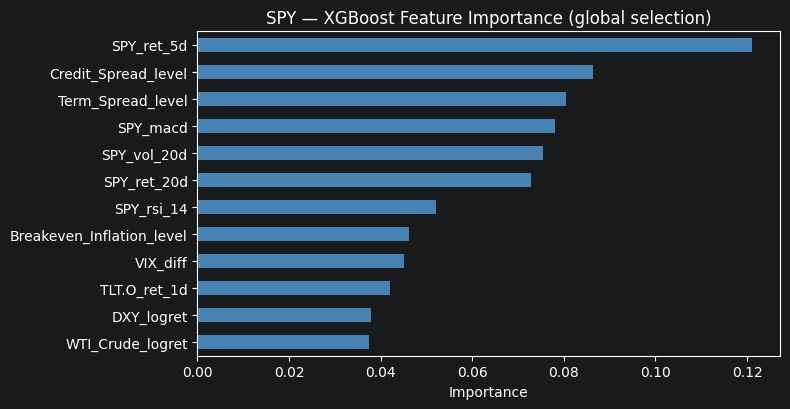

[SPY] selected features (12): ['SPY_ret_5d', 'Credit_Spread_level', 'Term_Spread_level', 'SPY_macd', 'SPY_vol_20d', 'SPY_ret_20d', 'SPY_rsi_14', 'Breakeven_Inflation_level', 'VIX_diff', 'TLT.O_ret_1d', 'DXY_logret', 'WTI_Crude_logret']



Best trial: 29. Best value: 5.48548: 100%|██████████| 30/30 [01:46<00:00,  3.55s/it]
/var/folders/tb/s30z0y490_v93zpcpl74ffn40000gn/T/ipykernel_43702/3040653312.py:26:ExperimentalWarning: optuna.visualization.matplotlib._optimization_history.plot_optimization_history is experimental (supported from v2.2.0). The interface can change in the future.


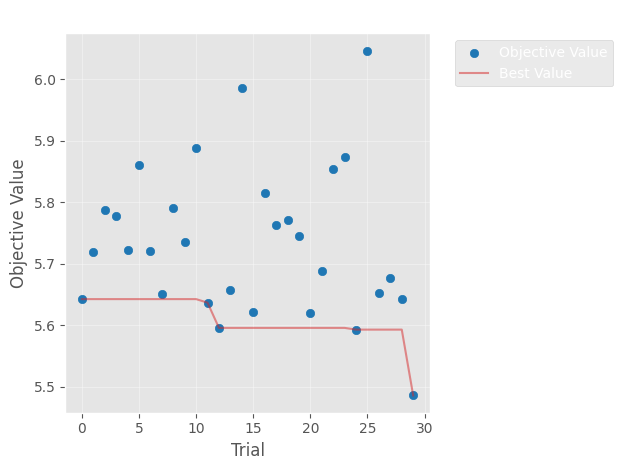

/var/folders/tb/s30z0y490_v93zpcpl74ffn40000gn/T/ipykernel_43702/3040653312.py:28:ExperimentalWarning: optuna.visualization.matplotlib._param_importances.plot_param_importances is experimental (supported from v2.2.0). The interface can change in the future.


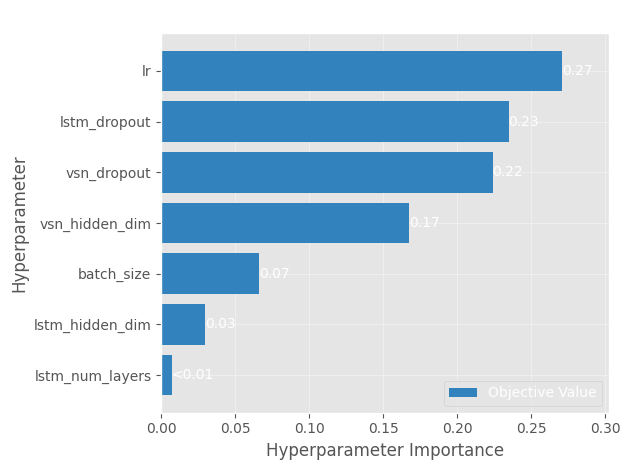

[SPY] best params: {'vsn_hidden_dim': 32, 'lstm_hidden_dim': 32, 'lstm_num_layers': 1, 'lstm_dropout': 0.12974515290810934, 'vsn_dropout': 0.23934122744344755, 'lr': 0.0036546282438620933, 'batch_size': 64}



targets:  25%|██▌       | 1/4 [16:09<48:27, 969.02s/it]   

  [SPY] saved to ../model/20260420_212808/
[SPY] walk-forward: n=4260, mse=6.647793, hit=0.463

[TLT.O] n=5562, folds=71


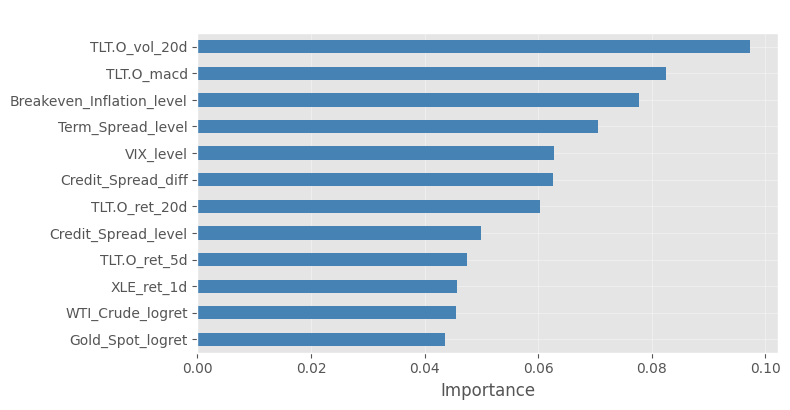

[TLT.O] selected features (12): ['TLT.O_vol_20d', 'TLT.O_macd', 'Breakeven_Inflation_level', 'Term_Spread_level', 'VIX_level', 'Credit_Spread_diff', 'TLT.O_ret_20d', 'Credit_Spread_level', 'TLT.O_ret_5d', 'XLE_ret_1d', 'WTI_Crude_logret', 'Gold_Spot_logret']



Best trial: 3. Best value: 4.32771: 100%|██████████| 30/30 [03:40<00:00,  7.35s/it]
/var/folders/tb/s30z0y490_v93zpcpl74ffn40000gn/T/ipykernel_43702/3040653312.py:26:ExperimentalWarning: optuna.visualization.matplotlib._optimization_history.plot_optimization_history is experimental (supported from v2.2.0). The interface can change in the future.


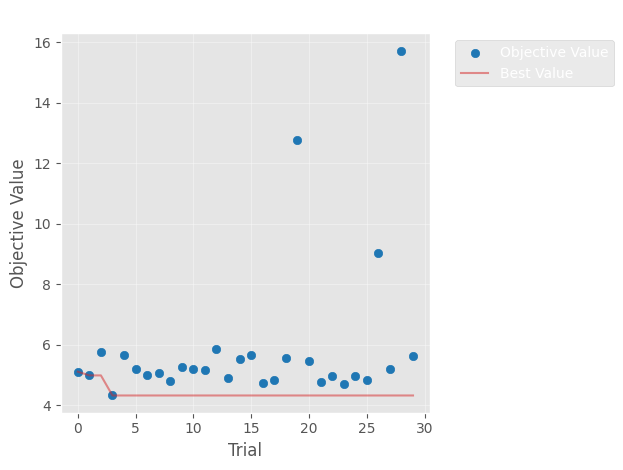

/var/folders/tb/s30z0y490_v93zpcpl74ffn40000gn/T/ipykernel_43702/3040653312.py:28:ExperimentalWarning: optuna.visualization.matplotlib._param_importances.plot_param_importances is experimental (supported from v2.2.0). The interface can change in the future.


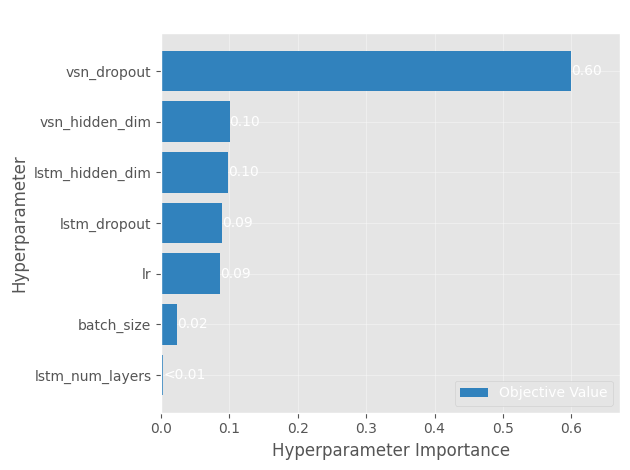

[TLT.O] best params: {'vsn_hidden_dim': 32, 'lstm_hidden_dim': 16, 'lstm_num_layers': 2, 'lstm_dropout': 0.10871512815442452, 'vsn_dropout': 0.24304854296721715, 'lr': 0.0035376654500754016, 'batch_size': 32}



targets:  50%|█████     | 2/4 [47:26<50:07, 1503.56s/it]    

  [TLT.O] saved to ../model/20260420_212808/
[TLT.O] walk-forward: n=4260, mse=5.635550, hit=0.502

[GLD] n=5562, folds=71


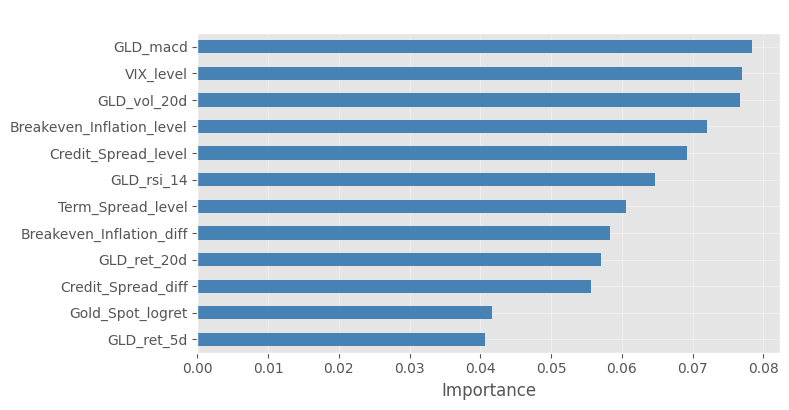

[GLD] selected features (12): ['GLD_macd', 'VIX_level', 'GLD_vol_20d', 'Breakeven_Inflation_level', 'Credit_Spread_level', 'GLD_rsi_14', 'Term_Spread_level', 'Breakeven_Inflation_diff', 'GLD_ret_20d', 'Credit_Spread_diff', 'Gold_Spot_logret', 'GLD_ret_5d']



Best trial: 10. Best value: 5.99781: 100%|██████████| 30/30 [02:27<00:00,  4.92s/it]
/var/folders/tb/s30z0y490_v93zpcpl74ffn40000gn/T/ipykernel_43702/3040653312.py:26:ExperimentalWarning: optuna.visualization.matplotlib._optimization_history.plot_optimization_history is experimental (supported from v2.2.0). The interface can change in the future.


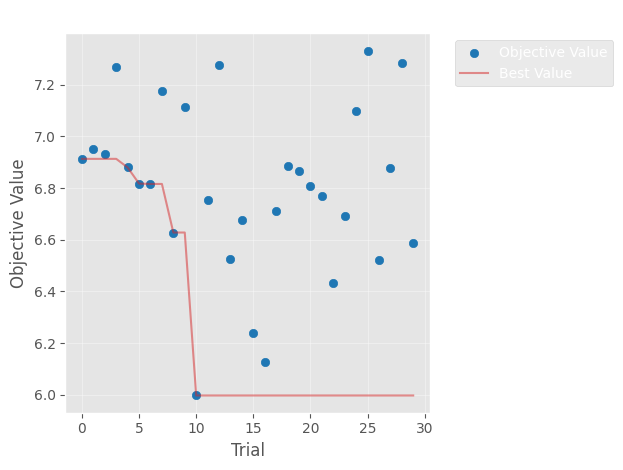

/var/folders/tb/s30z0y490_v93zpcpl74ffn40000gn/T/ipykernel_43702/3040653312.py:28:ExperimentalWarning: optuna.visualization.matplotlib._param_importances.plot_param_importances is experimental (supported from v2.2.0). The interface can change in the future.


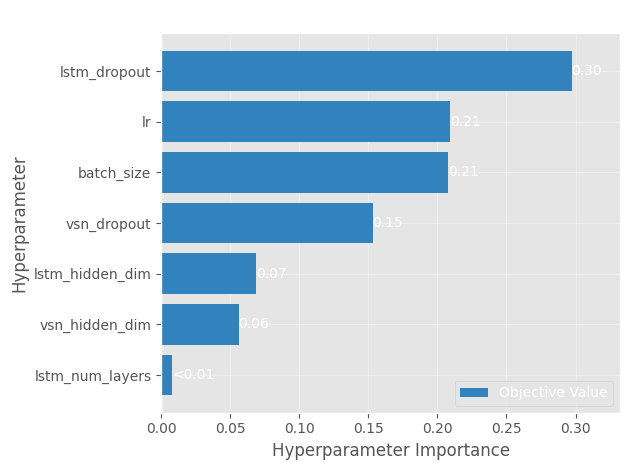

[GLD] best params: {'vsn_hidden_dim': 64, 'lstm_hidden_dim': 128, 'lstm_num_layers': 1, 'lstm_dropout': 0.29622306433065226, 'vsn_dropout': 0.02766254679510692, 'lr': 0.004178947700463648, 'batch_size': 128}



targets:  75%|███████▌  | 3/4 [58:52<18:50, 1130.34s/it]  

  [GLD] saved to ../model/20260420_212808/
[GLD] walk-forward: n=4260, mse=10.254776, hit=0.521

[XLE] n=5562, folds=71


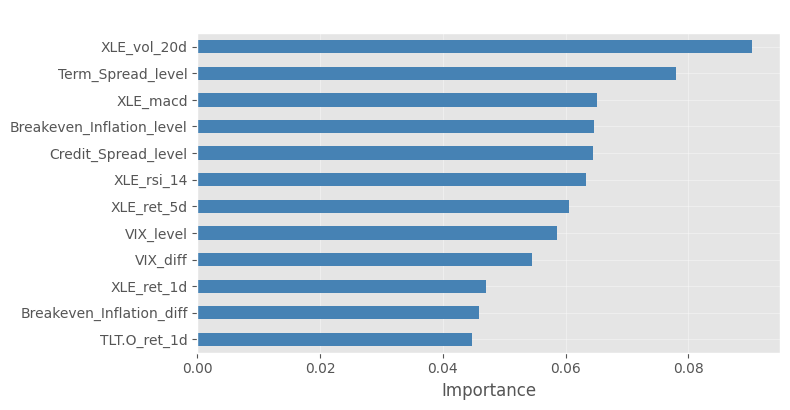

[XLE] selected features (12): ['XLE_vol_20d', 'Term_Spread_level', 'XLE_macd', 'Breakeven_Inflation_level', 'Credit_Spread_level', 'XLE_rsi_14', 'XLE_ret_5d', 'VIX_level', 'VIX_diff', 'XLE_ret_1d', 'Breakeven_Inflation_diff', 'TLT.O_ret_1d']



Best trial: 17. Best value: 6.59286: 100%|██████████| 30/30 [03:31<00:00,  7.05s/it]
/var/folders/tb/s30z0y490_v93zpcpl74ffn40000gn/T/ipykernel_43702/3040653312.py:26:ExperimentalWarning: optuna.visualization.matplotlib._optimization_history.plot_optimization_history is experimental (supported from v2.2.0). The interface can change in the future.


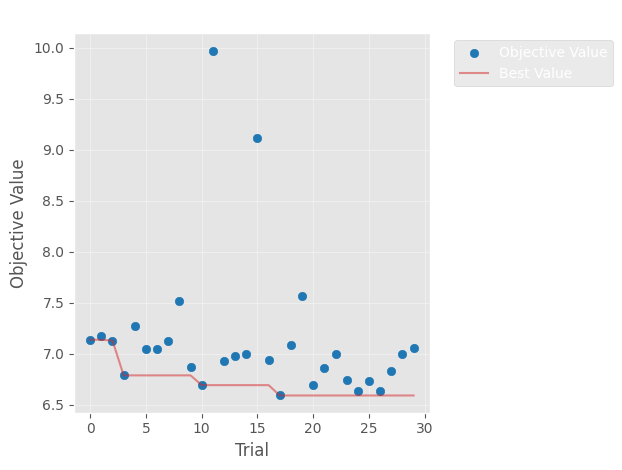

/var/folders/tb/s30z0y490_v93zpcpl74ffn40000gn/T/ipykernel_43702/3040653312.py:28:ExperimentalWarning: optuna.visualization.matplotlib._param_importances.plot_param_importances is experimental (supported from v2.2.0). The interface can change in the future.


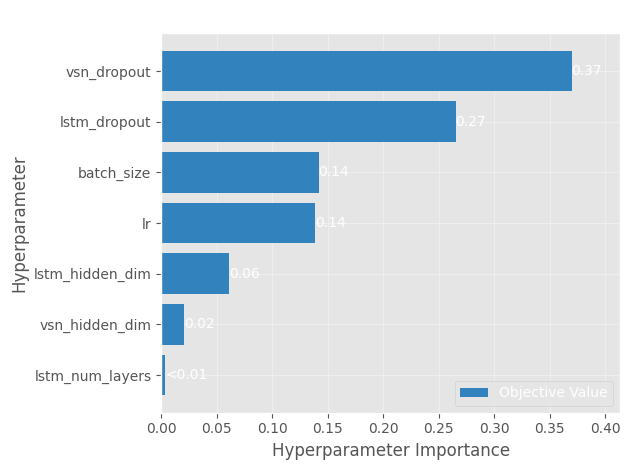

[XLE] best params: {'vsn_hidden_dim': 64, 'lstm_hidden_dim': 32, 'lstm_num_layers': 2, 'lstm_dropout': 0.06611308397679533, 'vsn_dropout': 0.10481977444471507, 'lr': 0.002335960437076757, 'batch_size': 32}



targets: 100%|██████████| 4/4 [1:32:05<00:00, 1381.29s/it]


  [XLE] saved to ../model/20260420_212808/
[XLE] walk-forward: n=4260, mse=7.003006, hit=0.488

Summary saved to ../model/20260420_212808/


,n,mse,hit
SPY,4260.0,6.647793,0.462911
TLT.O,4260.0,5.635550,0.502347
GLD,4260.0,10.254776,0.520657
XLE,4260.0,7.003006,0.488498


In [27]:
fold_results = {}
best_params_by_target = {}
feat_cols_by_target = {}

RUN_TS = dt.datetime.now().strftime("%Y%m%d_%H%M%S")
run_dir = f"{SAVE_DIR}/{RUN_TS}"
os.makedirs(run_dir, exist_ok=True)

for target in tqdm(TARGET_TICKERS, desc="targets"):
    data = datasets[target]
    n = len(data)
    initial_train = min(int(252 * INITIAL_TRAIN_YEARS), n // 2)
    folds = expanding_window_folds(n, initial_train, TEST_SIZE, EMBARGO)
    print(f"[{target}] n={n}, folds={len(folds)}")

    # ── Global feature selection (once on initial train period) ──────────────
    init_df  = data.iloc[:initial_train]
    X_init   = init_df.drop(columns=["target"])
    y_init   = init_df["target"]
    feat_cols, importances = select_features(X_init, y_init)
    feat_cols_by_target[target] = feat_cols

    # Feature importance chart
    importances.sort_values().plot.barh(
        figsize=(8, max(3, len(importances) * 0.35)),
        title=f"{target} — XGBoost Feature Importance (global selection)",
        color="steelblue",
    )
    plt.xlabel("Importance"); plt.tight_layout(); plt.show()
    print(f"[{target}] selected features ({len(feat_cols)}): {feat_cols}")

    # ── Optuna HPO ────────────────────────────────────────────────────────────
    study = tune_with_optuna(data, folds, feat_cols, n_trials=OPTUNA_TRIALS)
    best_params = study.best_params
    best_params_by_target[target] = best_params
    print(f"[{target}] best params: {best_params}")

    # ── Walk-forward training ─────────────────────────────────────────────────
    preds_df, last_model, last_mean, last_std, fold_hist = walk_forward(
        data, best_params, folds, feat_cols, desc=f"{target} folds"
    )
    mse = float(((preds_df["pred"] - preds_df["truth"]) ** 2).mean())
    hit = float(((preds_df["pred"] * preds_df["truth"]) > 0).mean())
    result = {
        "preds":       preds_df,
        "mse":         mse,
        "hit":         hit,
        "last_model":  last_model,
        "last_mean":   last_mean,
        "last_std":    last_std,
        "last_feats":  feat_cols,
        "fold_history": fold_hist,
    }
    fold_results[target] = result
    save_target(target, result, best_params, save_dir=run_dir)
    print(f"[{target}] walk-forward: n={len(preds_df)}, mse={mse:.6f}, hit={hit:.3f}\n")

summary_df = pd.DataFrame(
    {t: {"n": len(r["preds"]), "mse": r["mse"], "hit": r["hit"]}
     for t, r in fold_results.items()}
).T

with open(f"{run_dir}/best_params.json", "w") as f:
    json.dump(best_params_by_target, f, indent=2)
with open(f"{run_dir}/feat_cols.json", "w") as f:
    json.dump(feat_cols_by_target, f, indent=2)
summary_df.to_csv(f"{run_dir}/summary.csv")
print(f"Summary saved to {run_dir}/")
summary_df

In [28]:
def predict_next(model, feat_mean, feat_std, feats, recent_data,
                 lookback=LOOKBACK, vol_window=VOL_WINDOW, device="cpu"):
    """v4: Predict volatility-normalized return and recover an actual return estimate.

    Returns
    -------
    pred_return : float
        Estimated cumulative log return over next HORIZON days.
    pred_sharpe : float
        Raw model output (volatility-normalized return).
    feat_weights : dict
        Mean VSN feature weights over the lookback window.

    Notes
    -----
    `recent_data` must contain a column `close` (raw, unscaled) for the
    target asset so we can compute the current realised volatility used
    for de-normalization.
    """
    if len(recent_data) < lookback:
        raise ValueError(f"Need at least {lookback} rows, got {len(recent_data)}")

    window = recent_data[feats].iloc[-lookback:].values.astype(np.float32)
    scaled = ((window - feat_mean) / feat_std).astype(np.float32)
    x = torch.tensor(scaled[None, :, :]).to(device)
    model.to(device).eval()
    with torch.no_grad():
        pred, weights = model(x)
    w = weights.cpu().numpy()[0]

    pred_sharpe = float(pred.cpu().item())

    # De-normalise with current realised volatility (causal).
    if "close" in recent_data.columns:
        close = recent_data["close"].astype(float)
    else:
        # Fall back to the first column matching *Price Close*
        close_col = [c for c in recent_data.columns if "Price Close" in c][0]
        close = recent_data[close_col].astype(float)

    ret_1d  = np.log(close / close.shift(1))
    cur_vol = ret_1d.iloc[-vol_window:].std()
    pred_return = pred_sharpe * float(cur_vol)

    return pred_return, pred_sharpe, dict(zip(feats, w.mean(axis=0)))


In [29]:
# load_results() usage example (run in a new session after training):
#
# run_dir = "../model/20260419_143022"   # replace with your timestamped folder
# loaded  = load_results(run_dir)
# pred, weights = predict_next(
#     loaded["SPY"]["model"], loaded["SPY"]["feat_mean"], loaded["SPY"]["feat_std"],
#     loaded["SPY"]["feats"], recent_data=datasets["SPY"].drop(columns=["target"])
# )

# Validation

In [30]:
def validation_metrics(preds_df):
    p = preds_df["pred"].values
    t = preds_df["truth"].values
    return {
        "n": len(p),
        "mse": float(((p - t) ** 2).mean()),
        "mae": float(np.abs(p - t).mean()),
        "rmse": float(np.sqrt(((p - t) ** 2).mean())),
        "ic_spearman": float(pd.Series(p).corr(pd.Series(t), method="spearman")),
        "ic_pearson": float(pd.Series(p).corr(pd.Series(t), method="pearson")),
        "hit_ratio": float(((p * t) > 0).mean()),
    }

            n       mse      mae     rmse  ic_spearman  ic_pearson  hit_ratio
SPY    4260.0   6.64779  1.94984  2.57833      0.08920     0.07794    0.46291
TLT.O  4260.0   5.63555  1.81654  2.37393      0.01655     0.01816    0.50235
GLD    4260.0  10.25478  2.44767  3.20231      0.00461    -0.00657    0.52066
XLE    4260.0   7.00301  1.97466  2.64632      0.00814    -0.00969    0.48850


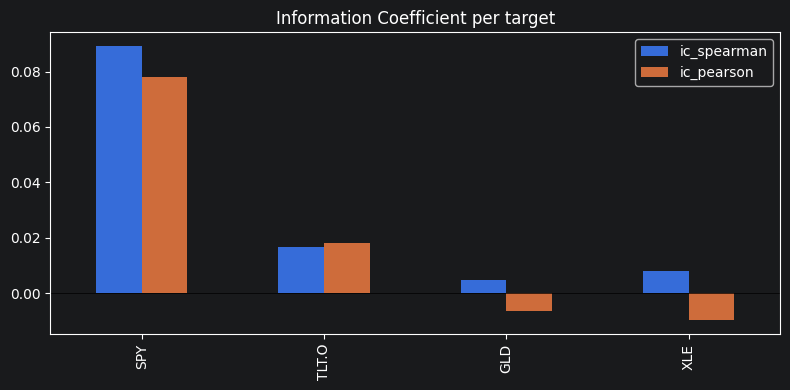

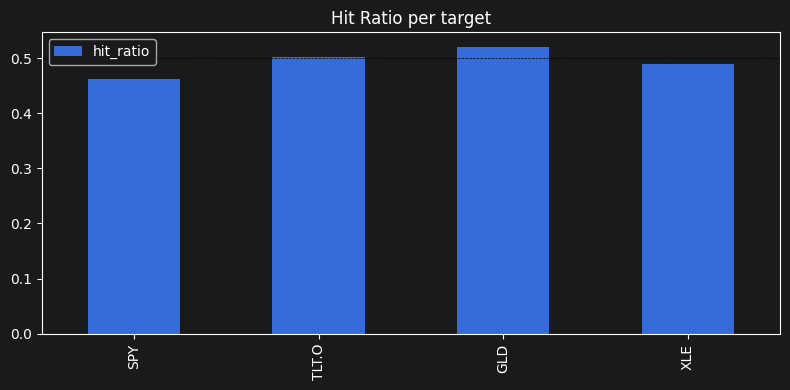

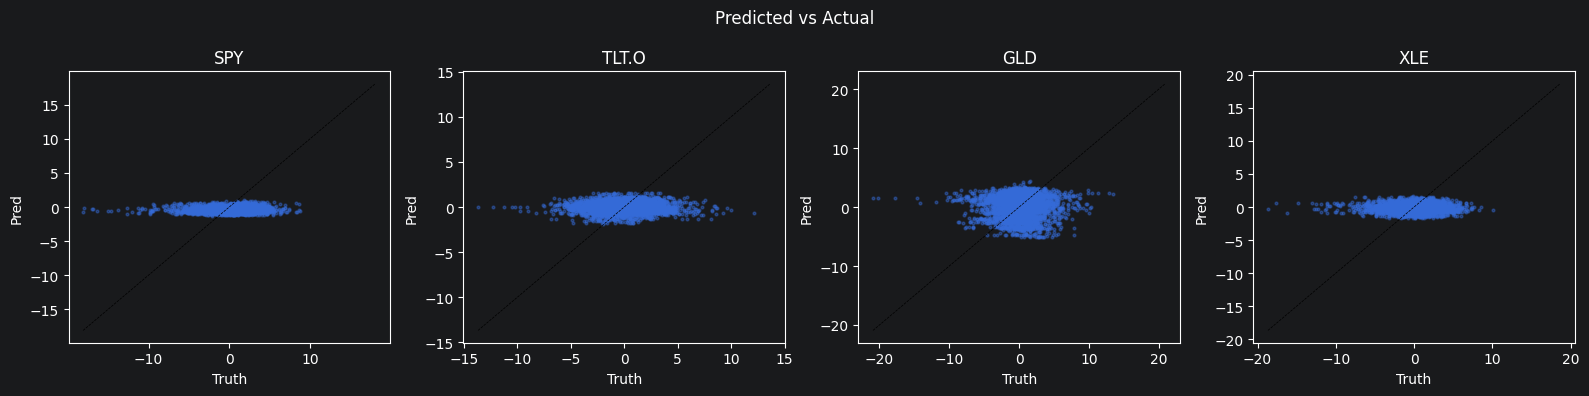

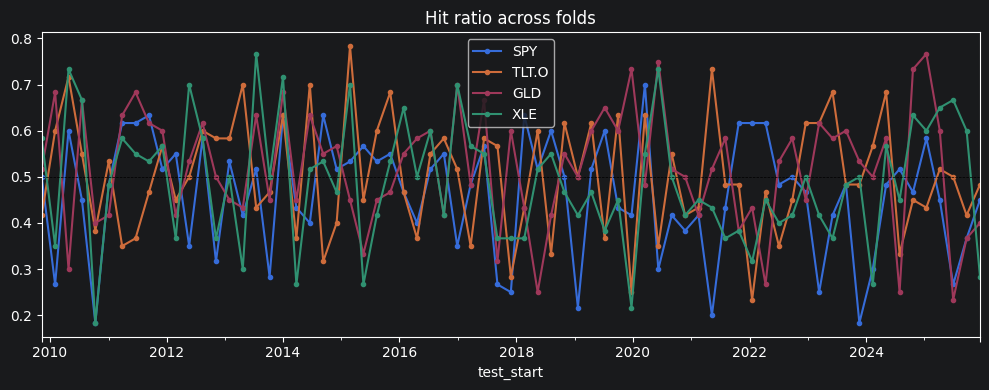

,n,mse,mae,rmse,ic_spearman,ic_pearson,hit_ratio
SPY,4260.0,6.64779,1.94984,2.57833,0.08920,0.07794,0.46291
TLT.O,4260.0,5.63555,1.81654,2.37393,0.01655,0.01816,0.50235
GLD,4260.0,10.25478,2.44767,3.20231,0.00461,-0.00657,0.52066
XLE,4260.0,7.00301,1.97466,2.64632,0.00814,-0.00969,0.48850


In [31]:
validation_df = pd.DataFrame(
    {t: validation_metrics(r["preds"]) for t, r in fold_results.items()}
).T
print(validation_df.round(5))

# (1) IC
validation_df[["ic_spearman", "ic_pearson"]].plot.bar(
    figsize=(8, 4), title="Information Coefficient per target")
plt.axhline(0, color="k", lw=0.5); plt.tight_layout(); plt.show()

# (2) Hit ratio
validation_df[["hit_ratio"]].plot.bar(
    figsize=(8, 4), title="Hit Ratio per target")
plt.axhline(0.5, color="k", ls="--", lw=0.5); plt.tight_layout(); plt.show()

# (3) Predicted vs Actual scatter
fig, axes = plt.subplots(1, len(TARGET_TICKERS), figsize=(4 * len(TARGET_TICKERS), 4))
axes = axes if len(TARGET_TICKERS) > 1 else [axes]
for ax, t in zip(axes, TARGET_TICKERS):
    df = fold_results[t]["preds"]
    ax.scatter(df["truth"], df["pred"], s=4, alpha=0.4)
    lim = max(df["truth"].abs().max(), df["pred"].abs().max())
    ax.plot([-lim, lim], [-lim, lim], "k--", lw=0.5)
    ax.set_title(t); ax.set_xlabel("Truth"); ax.set_ylabel("Pred")
plt.suptitle("Predicted vs Actual"); plt.tight_layout(); plt.show()

# (4) Fold-level Hit ratio stability
fig, ax = plt.subplots(figsize=(10, 4))
for t in TARGET_TICKERS:
    fh = fold_results[t]["fold_history"].set_index("test_start")
    fh["hit"].plot(ax=ax, marker="o", ms=3, label=t)
ax.axhline(0.5, color="k", ls="--", lw=0.5)
ax.set_title("Hit ratio across folds"); plt.legend(); plt.tight_layout(); plt.show()

validation_df.round(5)

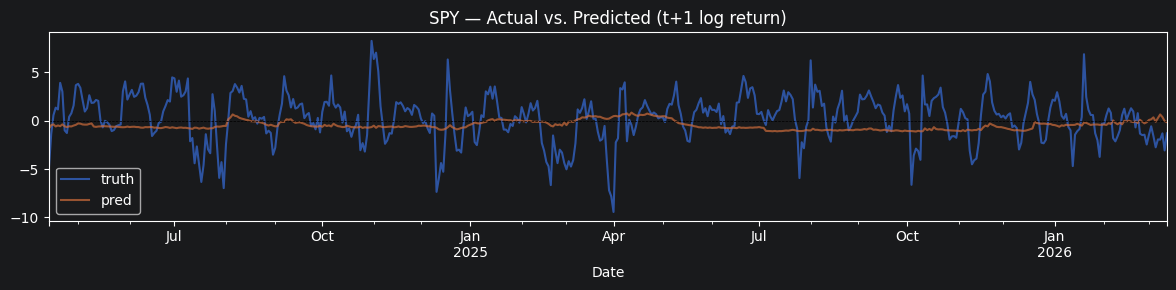

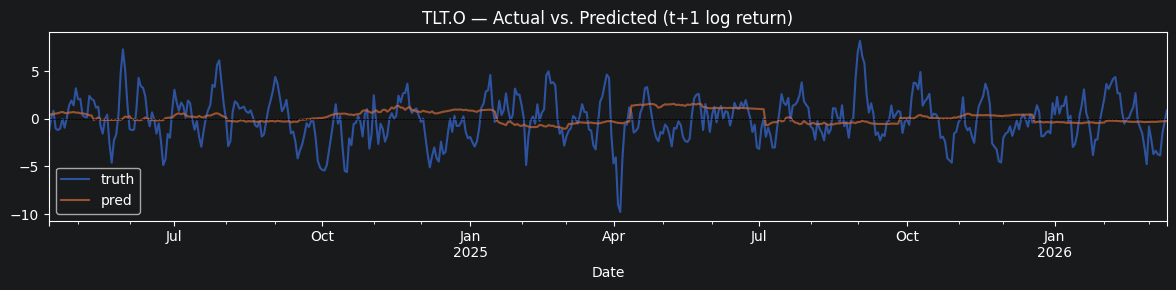

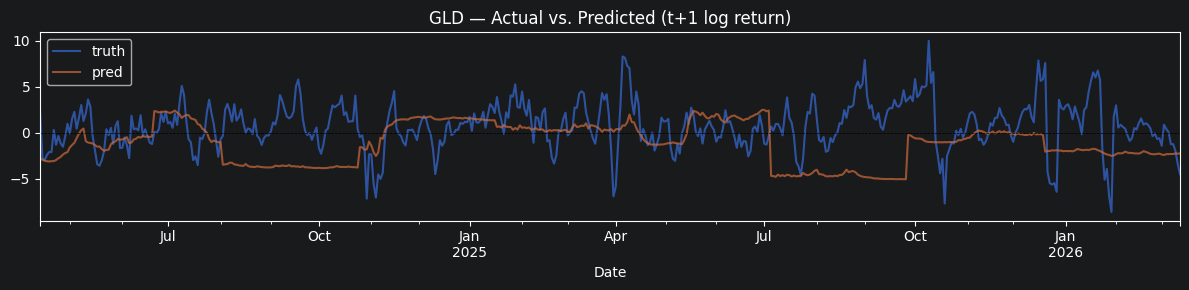

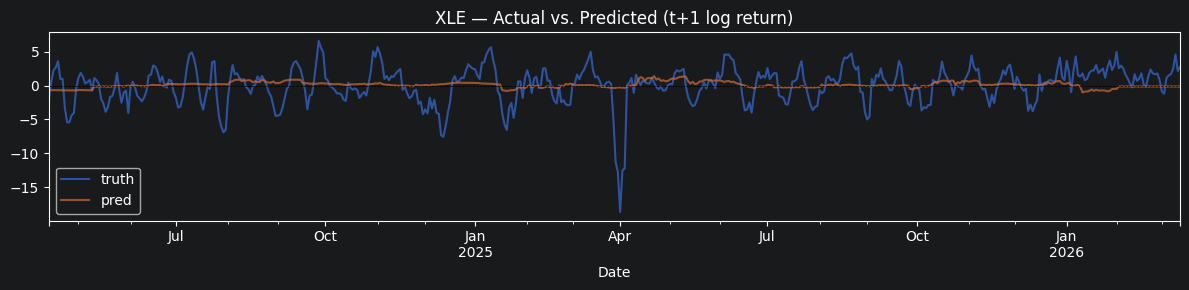

In [36]:
# Actual vs. Predicted time series per target
try:
    _results = fold_results
    _run_dir = run_dir
except NameError:
    _run_dir = "../model/YYYYMMDD_HHMMSS"   # ← replace with your folder
    _results = load_results(_run_dir)

for target, r in _results.items():
    preds_df = r["preds"]
    safe = target.replace(".", "_")
    ax = preds_df[-500:].plot(y=["truth", "pred"], figsize=(12, 3), alpha=0.7,
                       title=f"{target} — Actual vs. Predicted (t+1 log return)")
    ax.set_xlabel("Date")
    ax.axhline(0, color="k", lw=0.5, ls="--")
    plt.tight_layout()
    plt.savefig(f"{_run_dir}/{safe}_pred_vs_actual.png", dpi=100)
    plt.show()

# Backtesting

In [33]:
def backtest(preds_df, threshold=0.0):
    p = preds_df["pred"]
    t = preds_df["truth"]
    position = np.sign(p)
    if threshold > 0:
        position = position.where(p.abs() > threshold, 0)
    strat_ret = position * t
    bench_ret = t
    return pd.DataFrame({
        "position": position,
        "strat_ret": strat_ret,
        "bench_ret": bench_ret,
        "strat_eq": np.exp(strat_ret.cumsum()),
        "bench_eq": np.exp(bench_ret.cumsum()),
    }, index=preds_df.index)

In [34]:
def perf_metrics(ret, periods=252):
    ret = ret.dropna()
    if len(ret) == 0:
        return {}
    equity = np.exp(ret.cumsum())
    ann_ret = ret.mean() * periods
    ann_vol = ret.std() * np.sqrt(periods)
    sharpe = ann_ret / ann_vol if ann_vol > 0 else 0.0
    downside = ret[ret < 0].std() * np.sqrt(periods)
    sortino = ann_ret / downside if downside > 0 else 0.0
    dd = float((equity / equity.cummax() - 1).min())
    total_ret = float(equity.iloc[-1]) - 1
    years = len(ret) / periods
    cagr = (1 + total_ret) ** (1 / years) - 1 if years > 0 else 0.0
    calmar = cagr / abs(dd) if dd < 0 else 0.0
    return {
        "total_return": float(total_ret),
        "cagr": float(cagr),
        "ann_vol": float(ann_vol),
        "sharpe": float(sharpe),
        "sortino": float(sortino),
        "max_drawdown": dd,
        "calmar": float(calmar),
        "win_rate": float((ret > 0).mean()),
    }

        strat_total_return  strat_cagr  strat_ann_vol  strat_sharpe  \
target                                                                
SPY                   -1.0        -1.0        40.1675       -0.0928   
TLT.O                 -1.0        -1.0        36.8653       -0.1840   
GLD                    inf         inf        42.1498        0.1612   
XLE                   -1.0        -1.0        40.8933       -0.5176   

        strat_sortino  strat_max_drawdown  strat_calmar  strat_win_rate  \
target                                                                    
SPY           -0.1673                -1.0          -1.0          0.4629   
TLT.O         -0.2821                -1.0          -1.0          0.5023   
GLD            0.2212                -1.0           inf          0.5207   
XLE           -0.7515                -1.0          -1.0          0.4885   

        bench_total_return  bench_cagr  bench_ann_vol  bench_sharpe  \
target                                             

/Users/ahnsebin/Documents/GeorgiaTech/Spring26/GTSF IC/project/.venv/lib/python3.11/site-packages/pandas/core/arraylike.py:402:RuntimeWarning: overflow encountered in exp


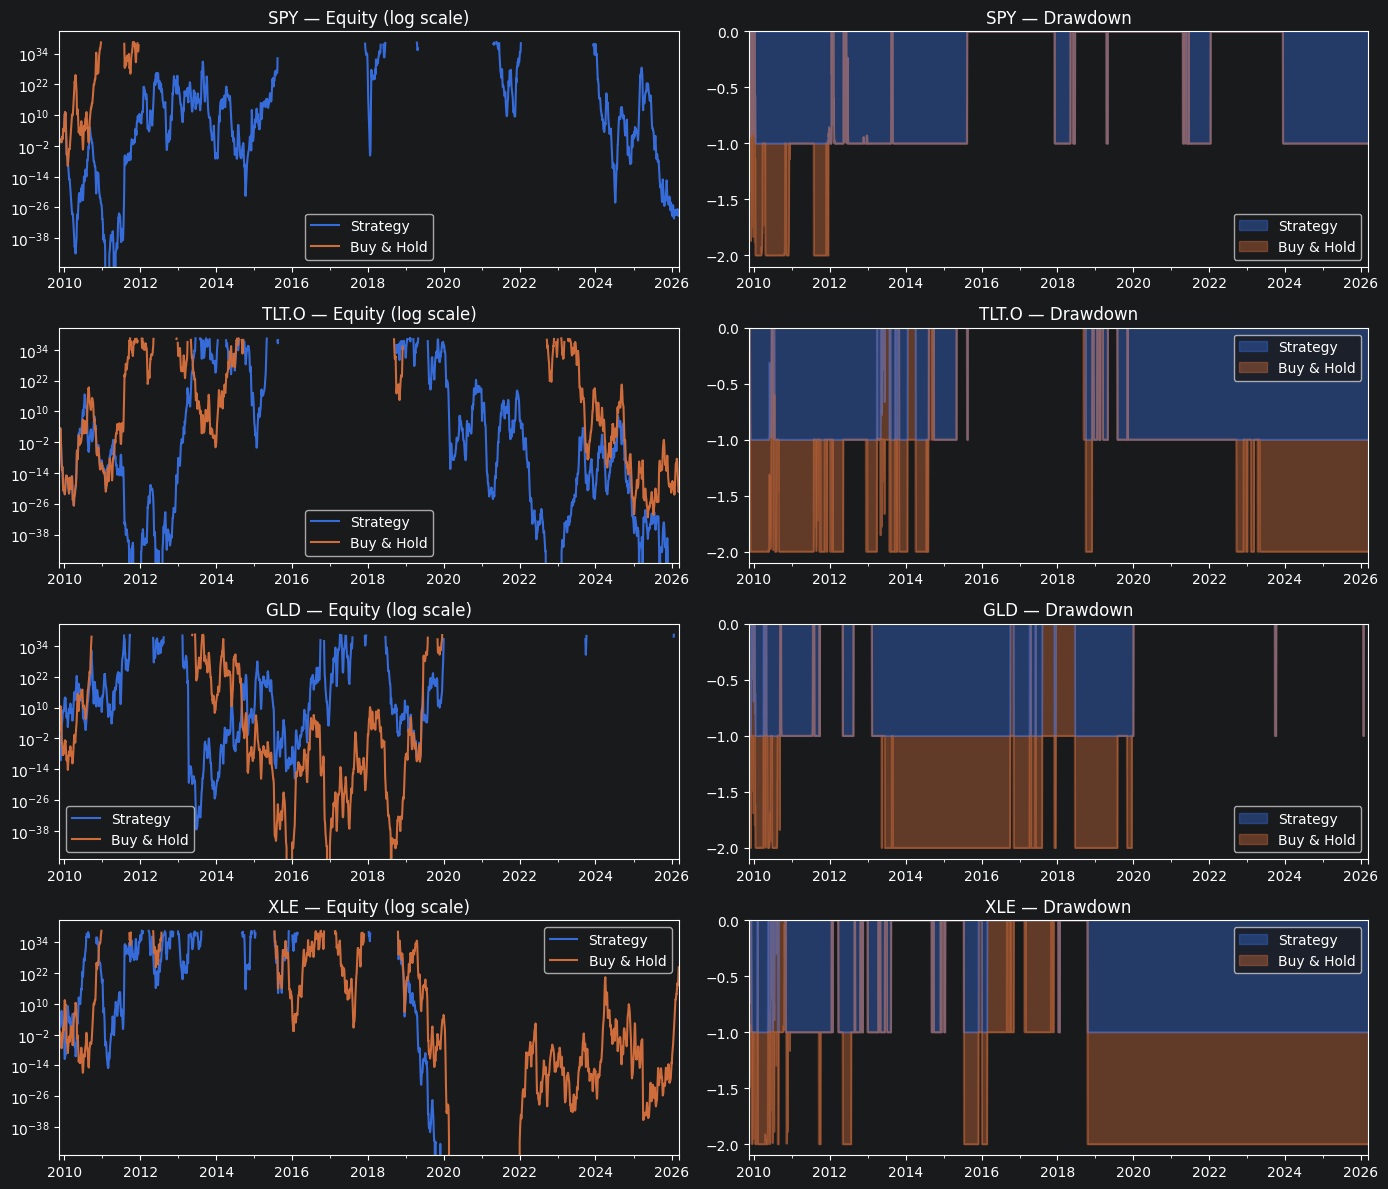

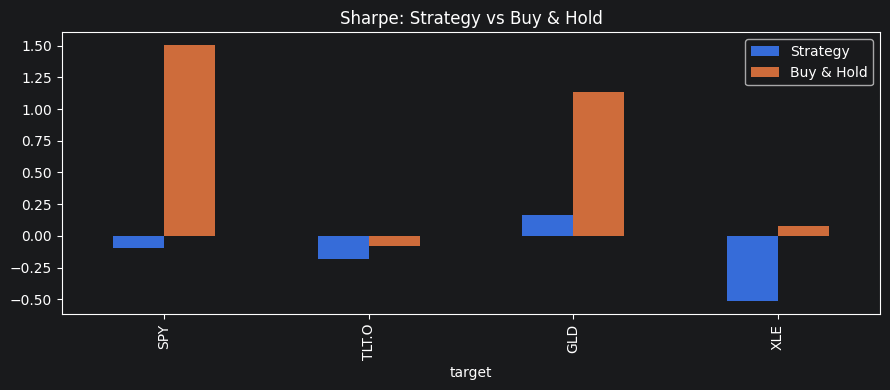

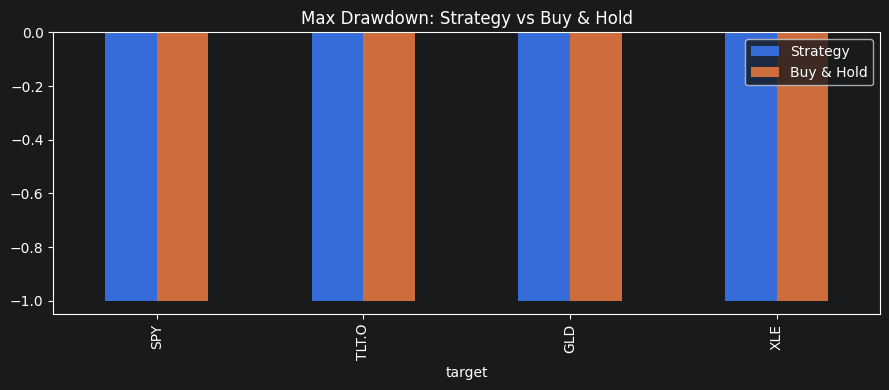

,strat_total_return,strat_cagr,strat_ann_vol,strat_sharpe,strat_sortino,strat_max_drawdown,strat_calmar,strat_win_rate,bench_total_return,bench_cagr,bench_ann_vol,bench_sharpe,bench_sortino,bench_max_drawdown,bench_calmar,bench_win_rate
target,,,,,,,,,,,,,,,,
SPY,-1.0,-1.0,40.1675,-0.0928,-0.1673,-1.0,-1.0,0.4629,inf,inf,39.9888,1.5051,1.7741,-1.0,inf,0.6045
TLT.O,-1.0,-1.0,36.8653,-0.1840,-0.2821,-1.0,-1.0,0.5023,-1.000000e+00,-1.0000,36.8674,-0.0777,-0.1182,-1.0,-1.0000,0.5138
GLD,inf,inf,42.1498,0.1612,0.2212,-1.0,inf,0.5207,inf,inf,42.0447,1.1347,1.5508,-1.0,inf,0.5505
XLE,-1.0,-1.0,40.8933,-0.5176,-0.7515,-1.0,-1.0,0.4885,2.037734e+24,26.4161,40.9145,0.0809,0.1022,-1.0,26.4161,0.5418


In [35]:
backtest_results = {t: backtest(r["preds"]) for t, r in fold_results.items()}

perf_rows = []
for t, bt in backtest_results.items():
    strat = perf_metrics(bt["strat_ret"])
    bench = perf_metrics(bt["bench_ret"])
    row = {"target": t}
    row.update({f"strat_{k}": v for k, v in strat.items()})
    row.update({f"bench_{k}": v for k, v in bench.items()})
    perf_rows.append(row)
perf_df = pd.DataFrame(perf_rows).set_index("target")
print(perf_df.round(4))

# Equity curves + drawdowns per target
fig, axes = plt.subplots(len(TARGET_TICKERS), 2, figsize=(14, 3 * len(TARGET_TICKERS)))
axes = axes.reshape(len(TARGET_TICKERS), 2)
for i, t in enumerate(TARGET_TICKERS):
    bt = backtest_results[t]
    bt[["strat_eq", "bench_eq"]].rename(columns={"strat_eq": "Strategy", "bench_eq": "Buy & Hold"}).plot(
        ax=axes[i, 0], logy=True, title=f"{t} — Equity (log scale)"
    )
    pd.DataFrame({
        "Strategy": bt["strat_eq"] / bt["strat_eq"].cummax() - 1,
        "Buy & Hold": bt["bench_eq"] / bt["bench_eq"].cummax() - 1,
    }).plot.area(ax=axes[i, 1], alpha=0.4, title=f"{t} — Drawdown")
plt.tight_layout(); plt.show()

# Sharpe + Max DD summary
perf_df[["strat_sharpe", "bench_sharpe"]].rename(
    columns={"strat_sharpe": "Strategy", "bench_sharpe": "Buy & Hold"}
).plot.bar(figsize=(9, 4), title="Sharpe: Strategy vs Buy & Hold")
plt.tight_layout(); plt.show()

perf_df[["strat_max_drawdown", "bench_max_drawdown"]].rename(
    columns={"strat_max_drawdown": "Strategy", "bench_max_drawdown": "Buy & Hold"}
).plot.bar(figsize=(9, 4), title="Max Drawdown: Strategy vs Buy & Hold")
plt.tight_layout(); plt.show()

perf_df.round(4)